In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

df = pd.read_csv('customer_booking.csv', encoding='latin-1')
print(df.shape)
print(df.dtypes)
print(df.head())

(50000, 14)
num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object
   num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2      Internet  RoundTrip            262              19   
1               1      Internet  RoundTrip            112              20   
2               2      Internet  RoundTrip            243              22   
3               1      Internet  RoundTrip             96              31   
4               2      Internet  RoundTrip             68              22   

   flight_hour flight_day   route booking_origin 

booking_complete
0    42522
1     7478
Name: count, dtype: int64
booking_complete
0    0.8504
1    0.1496
Name: proportion, dtype: float64
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64
       num_passengers  purchase_lead  length_of_stay  flight_hour  \
count    50000.000000   50000.000000     50000.00000  50000.00000   
mean         1.591240      84.940480        23.04456      9.06634   
std          1.020165      90.451378        33.88767      5.41266   
min          1.000000       0.000000         0.00000      0.00000   
25%          1.000000      21.000000         5.00000      5.00000   
50%          1.000000      51.000000        17.00000    

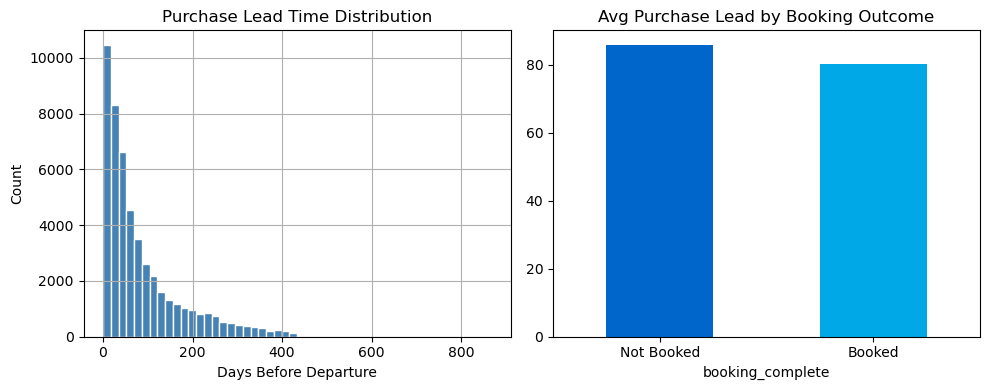

In [6]:
# Class balance check
print(df['booking_complete'].value_counts())
print(df['booking_complete'].value_counts(normalize=True).round(4))

# Missing values
print(df.isnull().sum())

# Basic statistics
print(df.describe())

# Booking rate by sales channel
print(df.groupby('sales_channel')['booking_complete'].mean().round(3))

# Booking rate by trip type
print(df.groupby('trip_type')['booking_complete'].mean().round(3))

# Distribution of purchase lead time
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['purchase_lead'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Purchase Lead Time Distribution')
plt.xlabel('Days Before Departure')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df.groupby('booking_complete')['purchase_lead'].mean().plot(kind='bar', color=['#0066CC','#00A8E8'])
plt.title('Avg Purchase Lead by Booking Outcome')
plt.xticks([0,1], ['Not Booked', 'Booked'], rotation=0)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [7]:
# 4 new features
df['total_extras'] = (
    df['wants_extra_baggage'] +
    df['wants_preferred_seat'] +
    df['wants_in_flight_meals']
)

df['is_weekend_flight'] = df['flight_day'].isin(['Sat', 'Sun']).astype(int)

df['short_lead'] = (df['purchase_lead'] <= 7).astype(int)

df['long_stay'] = (df['length_of_stay'] > 14).astype(int)

print("New features created:")
print(df[['total_extras', 'is_weekend_flight', 'short_lead', 'long_stay']].head())

New features created:
   total_extras  is_weekend_flight  short_lead  long_stay
0             1                  1           0          1
1             0                  1           0          1
2             2                  0           0          1
3             1                  1           0          1
4             2                  0           0          1


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sales_channel_enc'] = le.fit_transform(df['sales_channel'])
print("Sales channel:", dict(zip(le.classes_, le.transform(le.classes_))))

df['trip_type_enc'] = le.fit_transform(df['trip_type'])
print("Trip type:", dict(zip(le.classes_, le.transform(le.classes_))))

Sales channel: {'Internet': 0, 'Mobile': 1}
Trip type: {'CircleTrip': 0, 'OneWay': 1, 'RoundTrip': 2}


In [10]:
features = [
    'num_passengers',
    'purchase_lead',
    'length_of_stay',
    'flight_hour',
    'flight_duration',
    'wants_extra_baggage',
    'wants_preferred_seat',
    'wants_in_flight_meals',
    'sales_channel_enc',
    'trip_type_enc',
    'total_extras',
    'is_weekend_flight',
    'short_lead',
    'long_stay'
]

X = df[features]
y = df['booking_complete']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (50000, 14)
Target distribution:
 booking_complete
0    42522
1     7478
Name: count, dtype: int64


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
print("Model trained successfully.")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Model trained successfully.
Training samples: 40000, Test samples: 10000


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_acc   = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
cv_roc   = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
cv_f1    = cross_val_score(rf, X, y, cv=cv, scoring='f1')

print("=" * 45)
print(f"CV Accuracy:  {cv_acc.mean():.4f}  ±  {cv_acc.std():.4f}")
print(f"CV ROC-AUC:   {cv_roc.mean():.4f}  ±  {cv_roc.std():.4f}")
print(f"CV F1 Score:  {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}")
print("=" * 45)

CV Accuracy:  0.6971  ±  0.0048
CV ROC-AUC:   0.6770  ±  0.0029
CV F1 Score:  0.3390  ±  0.0041


In [13]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Booked', 'Booked']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

  Not Booked       0.90      0.72      0.80      8504
      Booked       0.25      0.54      0.35      1496

    accuracy                           0.70     10000
   macro avg       0.58      0.63      0.57     10000
weighted avg       0.80      0.70      0.73     10000

Test ROC-AUC: 0.6813


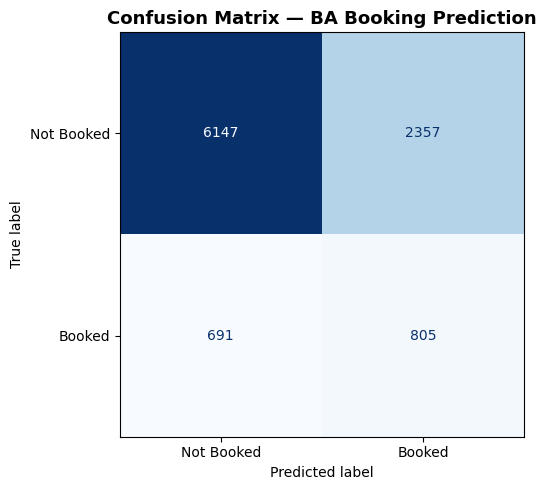

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Booked', 'Booked'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — BA Booking Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

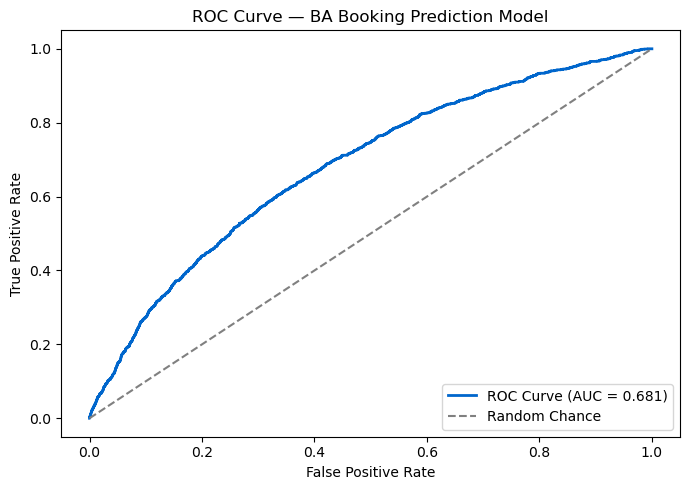

In [15]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#0066CC', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='grey', linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — BA Booking Prediction Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

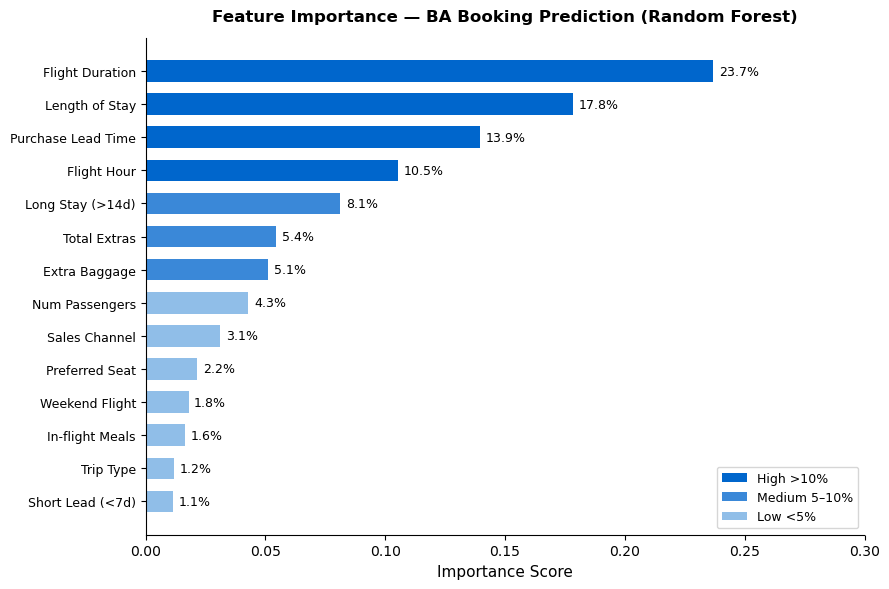

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

features = [
    'num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
    'flight_duration', 'wants_extra_baggage', 'wants_preferred_seat',
    'wants_in_flight_meals', 'sales_channel_enc', 'trip_type_enc',
    'total_extras', 'is_weekend_flight', 'short_lead', 'long_stay'
]

labels_map = {
    'flight_duration':       'Flight Duration',
    'length_of_stay':        'Length of Stay',
    'purchase_lead':         'Purchase Lead Time',
    'flight_hour':           'Flight Hour',
    'long_stay':             'Long Stay (>14d)',
    'total_extras':          'Total Extras',
    'wants_extra_baggage':   'Extra Baggage',
    'num_passengers':        'Num Passengers',
    'sales_channel_enc':     'Sales Channel',
    'wants_preferred_seat':  'Preferred Seat',
    'is_weekend_flight':     'Weekend Flight',
    'wants_in_flight_meals': 'In-flight Meals',
    'trip_type_enc':         'Trip Type',
    'short_lead':            'Short Lead (<7d)',
}

importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.index = [labels_map[i] for i in importances.index]

colors = ['#0066CC' if v >= 0.10 else '#3A88D8' if v >= 0.05 else '#90BEE8'
          for v in importances.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor='none', height=0.65)
ax.bar_label(bars, labels=[f'{v:.1%}' for v in importances.values],
             padding=4, fontsize=9)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance — BA Booking Prediction (Random Forest)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 0.30)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

legend_elements = [
    Patch(facecolor='#0066CC', label='High >10%'),
    Patch(facecolor='#3A88D8', label='Medium 5–10%'),
    Patch(facecolor='#90BEE8', label='Low <5%')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()